# Taller 4 — Generación de texto con GPT aplicada a PRUNIN

## Generación de incidencias técnicas a partir de issues reales de GitHub

Este notebook desarrolla un caso propio de **generación de texto** utilizando un modelo tipo GPT y un dataset real de incidencias de software.

La idea se conecta con **PRUNIN** porque una capacidad futura del proyecto podría ser generar borradores de incidencias, escenarios técnicos o descripciones iniciales a partir del lenguaje observado en proyectos reales.

### Fuente de datos

Se utiliza el dataset público de Hugging Face:

**`noamaanMulla-03/datasets-issues`**

El dataset fue construido a partir de la API REST de GitHub y contiene issues y pull requests reales del repositorio `huggingface/datasets`. Para este taller se utilizarán únicamente los **issues reales**, excluyendo pull requests.

Fuente: https://huggingface.co/datasets/noamaanMulla-03/datasets-issues

---

## Pregunta de investigación

> **¿Puede un modelo tipo GPT aprender los patrones lingüísticos presentes en incidencias reales de proyectos de software y generar nuevos textos coherentes con ese dominio?**

Como segunda pregunta experimental:

> **¿Cómo cambia el desempeño y la calidad de las generaciones al modificar la capacidad del modelo y los parámetros de decodificación?**

---

## Relación con la sesión

La sesión explica el principio autoregresivo de GPT:

**tokens anteriores → predicción del siguiente token → repetición del proceso**

En este notebook se conserva esa idea central. Los hiperparámetros utilizados aquí forman parte del caso propio y se comparan experimentalmente.

# 1. Objetivos

## Objetivo general

Construir y evaluar un modelo generativo tipo GPT capaz de aprender patrones textuales presentes en incidencias reales de proyectos de software.

## Objetivos específicos

1. Cargar automáticamente un dataset real desde Hugging Face.
2. Seleccionar únicamente issues y excluir pull requests.
3. Realizar un EDA del corpus.
4. Preparar el texto de títulos y descripciones.
5. Construir secuencias para entrenamiento autoregresivo.
6. Entrenar dos configuraciones de un modelo GPT pequeño.
7. Comparar pérdida y perplexity.
8. Analizar el efecto de distintos parámetros de decodificación.
9. Generar nuevas incidencias a partir de prompts.
10. Construir una pequeña demo interactiva.
11. Analizar limitaciones y posibles usos posteriores dentro de PRUNIN.

# 2. Alcance y criterio del caso

La tarea es **generación de texto**, no clasificación.

La unidad de información será una incidencia real de GitHub representada de esta forma:

```text
<TITLE> título del issue
<BODY> descripción del issue
```

El modelo aprenderá a predecir el siguiente token utilizando únicamente los tokens anteriores.

### Qué no se hará

- No se utilizarán datos sintéticos para entrenar.
- No se utilizarán las respuestas generadas como si fueran datos reales.
- No se pretende demostrar que el modelo esté listo para producción.
- No se utilizarán LLMs externos para generar el corpus de entrenamiento.

Las generaciones al final del notebook son **salidas experimentales del modelo entrenado**.

# 3. Instalación e importaciones

La primera celda instala únicamente las dependencias necesarias.  
En VS Code puede ejecutarse una sola vez por entorno virtual.

In [ ]:
%pip install -q datasets transformers pandas numpy matplotlib torch scikit-learn

In [2]:
import os
import re
import math
import time
import random
from copy import deepcopy
from pathlib import Path
from collections import Counter
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from transformers import GPT2TokenizerFast, GPT2Config, GPT2LMHeadModel

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Dispositivo:", DEVICE)
print("PyTorch:", torch.__version__)

Dispositivo: mps
PyTorch: 2.14.0


# 4. Carga automática del dataset real

Una decisión importante para la **reproducibilidad** es no depender de una ruta local.

El notebook descarga el dataset directamente desde Hugging Face:

```python
load_dataset("noamaanMulla-03/datasets-issues")
```

De acuerdo con la tarjeta del dataset, contiene 8.084 filas entre issues y pull requests.  
La columna `is_pull_request` permite separar ambos tipos.

In [3]:
DATASET_ID = "noamaanMulla-03/datasets-issues"

hf_dataset = load_dataset(
    DATASET_ID,
    split="train"
)

print(hf_dataset)
print("\nColumnas disponibles:")
print(hf_dataset.column_names)

README.md:   0%|          | 0.00/16.0k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 39.3MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/8084 [00:00<?, ? examples/s]

Dataset({
    features: ['url', 'repository_url', 'labels_url', 'comments_url', 'events_url', 'html_url', 'id', 'node_id', 'number', 'title', 'user', 'labels', 'state', 'locked', 'assignees', 'milestone', 'comments', 'created_at', 'updated_at', 'closed_at', 'assignee', 'author_association', 'issue_field_values', 'type', 'active_lock_reason', 'draft', 'pull_request', 'body', 'closed_by', 'reactions', 'timeline_url', 'performed_via_github_app', 'state_reason', 'sub_issues_summary', 'issue_dependencies_summary', 'pinned_comment', 'is_pull_request', 'comments_text'],
    num_rows: 8084
})

Columnas disponibles:
['url', 'repository_url', 'labels_url', 'comments_url', 'events_url', 'html_url', 'id', 'node_id', 'number', 'title', 'user', 'labels', 'state', 'locked', 'assignees', 'milestone', 'comments', 'created_at', 'updated_at', 'closed_at', 'assignee', 'author_association', 'issue_field_values', 'type', 'active_lock_reason', 'draft', 'pull_request', 'body', 'closed_by', 'reactions', 'timel

In [4]:
df_raw = hf_dataset.to_pandas()

print("Filas totales:", len(df_raw))
print("Columnas:", len(df_raw.columns))

display(
    df_raw[
        ["number", "title", "body", "state", "is_pull_request"]
    ].head()
)

Filas totales: 8084
Columnas: 38


,number,title,body,state,is_pull_request
0,20,remove boto3 and promise dependencies,"With the new download manager, we don't need `...",closed,True
1,17,Add Pandas as format type,As detailed in the title ^^,closed,True
2,22,adding bleu score code,this PR add the BLEU score metric to the lib. ...,closed,True
3,5,ValueError when a split is empty,"When a split is empty either TEST, VALIDATION ...",closed,False
4,6,Error when citation is not given in the Datase...,The following error is raised when the `citati...,closed,False


# 5. Selección de issues reales y control de calidad

El endpoint de GitHub retorna tanto issues como pull requests. Para que el caso se enfoque en incidencias, se conservan únicamente las filas donde:

```text
is_pull_request == False
```

También se eliminan títulos vacíos y duplicados exactos.

In [5]:
df = df_raw[
    df_raw["is_pull_request"] == False
].copy()

df["title"] = (
    df["title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df["body"] = (
    df["body"]
    .fillna("")
    .astype(str)
)

df = df[
    df["title"].str.len() > 0
].copy()

print("Issues reales antes de eliminar duplicados:", len(df))

duplicados = df["title"].str.lower().duplicated().sum()
print("Títulos duplicados:", duplicados)

df = (
    df
    .assign(_title_key=df["title"].str.lower())
    .drop_duplicates("_title_key")
    .drop(columns="_title_key")
    .reset_index(drop=True)
)

print("Issues finales disponibles:", len(df))

Issues reales antes de eliminar duplicados: 3293
Títulos duplicados: 17
Issues finales disponibles: 3276


# 6. EDA — Análisis exploratorio del corpus

El EDA busca responder:

- ¿Cuántos issues tenemos?
- ¿Cuántos tienen descripción?
- ¿Qué tan largos son?
- ¿Cuáles son las palabras y bigramas frecuentes?
- ¿Qué labels aparecen con mayor frecuencia?

Esto permite entender el corpus antes de entrenar.

In [6]:
df["title_words"] = df["title"].str.split().str.len()
df["body_words"] = df["body"].str.split().str.len()
df["has_body"] = df["body"].str.strip().str.len() > 0

print("Issues:", len(df))
print("Con body:", int(df["has_body"].sum()))
print("Sin body:", int((~df["has_body"]).sum()))

display(
    df[["title_words", "body_words"]].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Issues: 3276
Con body: 3254
Sin body: 22


,title_words,body_words
count,3276.000000,3276.00000
mean,7.419719,184.86569
std,3.772131,302.24748
min,1.000000,0.00000
50%,7.000000,128.00000
75%,9.000000,222.00000
90%,12.000000,367.00000
95%,14.000000,492.25000
99%,18.000000,1034.75000
max,44.000000,12223.00000


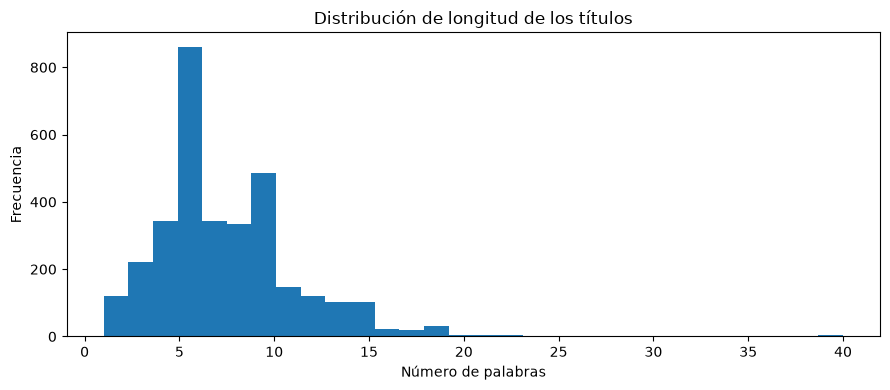

In [7]:
plt.figure(figsize=(9, 4))
plt.hist(
    df["title_words"].clip(upper=40),
    bins=30
)
plt.title("Distribución de longitud de los títulos")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### Lectura del gráfico

Los títulos de issues suelen ser breves. Esto es útil para generación porque el modelo puede aprender patrones de formulación como:

- reportar un fallo;
- solicitar soporte;
- describir una mejora;
- expresar un comportamiento inesperado.

El `body` aporta contexto adicional, por lo que se utilizarán ambos campos.

,token,frecuencia
0,dataset,1004
1,not,361
2,datasets,357
3,error,294
4,add,206
5,loading,204
6,load_dataset,163
7,data,161
8,load,150
9,cannot,127


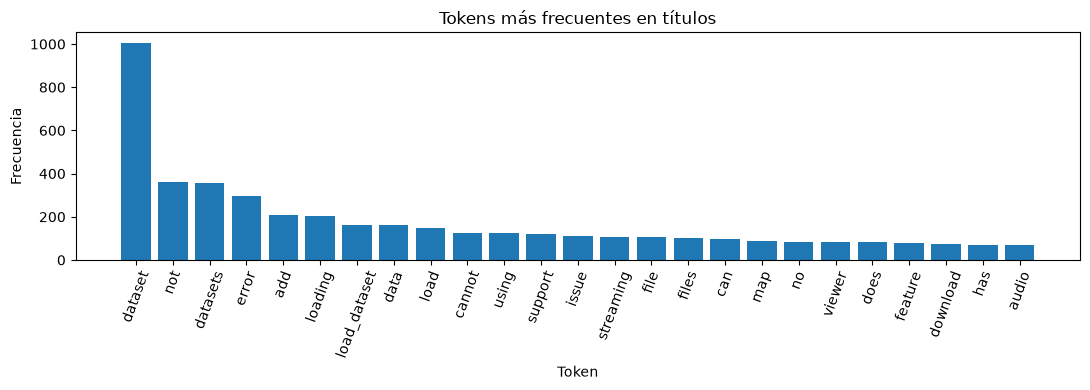

In [8]:
def normalizar_para_eda(texto):
    texto = str(texto).lower()
    texto = re.sub(r"https?://\S+", " ", texto)
    texto = re.sub(r"[^a-z0-9_+#.\-\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

STOPWORDS_EDA = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on",
    "for", "with", "is", "are", "was", "were", "be", "been",
    "by", "from", "at", "as", "it", "this", "that", "these",
    "those", "into", "i", "we", "you", "when", "if"
}

tokens = []

for title in df["title"]:
    for token in normalizar_para_eda(title).split():
        if token not in STOPWORDS_EDA and len(token) > 1:
            tokens.append(token)

top_words = pd.DataFrame(
    Counter(tokens).most_common(25),
    columns=["token", "frecuencia"]
)

display(top_words)

plt.figure(figsize=(11, 4))
plt.bar(
    top_words["token"],
    top_words["frecuencia"]
)
plt.title("Tokens más frecuentes en títulos")
plt.xlabel("Token")
plt.ylabel("Frecuencia")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    min_df=3,
    stop_words="english"
)

X_bigrams = vectorizer.fit_transform(df["title"])
freq = np.asarray(X_bigrams.sum(axis=0)).ravel()
names = np.array(vectorizer.get_feature_names_out())

idx = np.argsort(freq)[::-1][:20]

bigrams_df = pd.DataFrame({
    "bigrama": names[idx],
    "frecuencia": freq[idx]
})

display(bigrams_df)

,bigrama,frecuencia
0,dataset viewer,76
1,viewer issue,56
2,dataset map,44
3,loading dataset,32
4,error loading,32
5,feature request,30
6,pyarrow lib,25
7,does work,25
8,load dataset,24
9,map function,21


## 6.1 Labels reales del repositorio

Los labels no se usarán como objetivo de entrenamiento, pero sirven para conocer el dominio del corpus.

In [10]:
def extraer_label_names(labels):
    if labels is None:
        return []

    if isinstance(labels, np.ndarray):
        labels = labels.tolist()

    if not isinstance(labels, (list, tuple)):
        return []

    names = []

    for item in labels:
        if isinstance(item, dict):
            name = item.get("name")
            if name:
                names.append(str(name))

    return names

all_labels = []

for labels in df["labels"]:
    all_labels.extend(
        extraer_label_names(labels)
    )

top_labels = pd.DataFrame(
    Counter(all_labels).most_common(15),
    columns=["label", "frecuencia"]
)

display(top_labels)

,label,frecuencia
0,bug,706
1,enhancement,501
2,dataset request,161
3,dataset-viewer,86
4,dataset bug,74
5,good first issue,53
6,duplicate,30
7,generic discussion,27
8,documentation,27
9,question,24


# 7. Construcción del corpus para generación

Se combinan `title` y `body`.

Para evitar que descripciones extremadamente largas dominen el corpus, se conserva una porción inicial del body. Esta decisión no genera datos nuevos; únicamente limita la longitud de cada documento.

Formato:

```text
<TITLE> ...
<BODY> ...
```

In [11]:
MAX_BODY_CHARS = 1200

def limpiar_body(texto):
    texto = str(texto)

    # URLs largas generan ruido innecesario.
    texto = re.sub(
        r"https?://\S+",
        "<URL>",
        texto
    )

    # Bloques de código muy largos se sustituyen por una marca.
    texto = re.sub(
        r"```.*?```",
        " <CODE> ",
        texto,
        flags=re.DOTALL
    )

    texto = re.sub(
        r"\s+",
        " ",
        texto
    ).strip()

    return texto[:MAX_BODY_CHARS]

def construir_documento(row):
    title = str(row["title"]).strip()
    body = limpiar_body(row["body"])

    if body:
        return f"<TITLE> {title}\n<BODY> {body}"

    return f"<TITLE> {title}"

df["text"] = df.apply(
    construir_documento,
    axis=1
)

display(
    df[["title", "text"]].head(3)
)

,title,text
0,ValueError when a split is empty,<TITLE> ValueError when a split is empty\n<BOD...
1,Error when citation is not given in the Datase...,<TITLE> Error when citation is not given in th...
2,[Feature] More dataset outputs,<TITLE> [Feature] More dataset outputs\n<BODY>...


# 8. División Train / Validation / Test

Se utiliza una división reproducible:

- **80 % Train**
- **10 % Validation**
- **10 % Test**

Test se reserva para la evaluación final.

In [12]:
indices = np.arange(len(df))

rng = np.random.default_rng(SEED)
rng.shuffle(indices)

n = len(indices)
n_train = int(n * 0.80)
n_val = int(n * 0.10)

idx_train = indices[:n_train]
idx_val = indices[n_train:n_train + n_val]
idx_test = indices[n_train + n_val:]

train_df = df.iloc[idx_train].reset_index(drop=True)
val_df = df.iloc[idx_val].reset_index(drop=True)
test_df = df.iloc[idx_test].reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2620
Validation: 327
Test: 329


# 9. Tokenización

Se usa **GPT2TokenizerFast**, descargado automáticamente, para convertir el texto en tokens subword de GPT-2.

**No se cargan pesos preentrenados de GPT-2 para el modelo.** `GPT2LMHeadModel` implementa la arquitectura; al construirlo con `GPT2Config`, sus pesos se inicializan aleatoriamente. El modelo aprende únicamente del corpus real de issues de este taller. El tokenizador y los pesos del modelo son componentes distintos.

In [13]:
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")

# GPT-2 no trae PAD por defecto.
tokenizer.pad_token = tokenizer.eos_token

BLOCK_SIZE = 96

ejemplo = train_df["text"].iloc[0]

tokens_ejemplo = tokenizer.tokenize(
    ejemplo
)

ids_ejemplo = tokenizer.encode(
    ejemplo
)

print("Texto:")
print(ejemplo[:500])

print("\nPrimeros tokens:")
print(tokens_ejemplo[:30])

print("\nPrimeros IDs:")
print(ids_ejemplo[:30])

print("\nNúmero de tokens:", len(ids_ejemplo))

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Texto:
<TITLE> Consistent caching between python and jupyter
<BODY> ### Feature request I hope this is not my mistake, currently if I use `load_dataset` from a python session on a custom dataset to do the preprocessing, it will be saved in the cache and in other python sessions it will be loaded from the cache, however calling the same from a jupyter notebook does not work, meaning the preprocessing starts from scratch. If adjusting the hashes is impossible, is there a way to manually set dataset finge

Primeros tokens:
['<', 'TIT', 'LE', '>', 'ĠCons', 'istent', 'Ġcaching', 'Ġbetween', 'Ġpython', 'Ġand', 'Ġj', 'up', 'y', 'ter', 'Ċ', '<', 'B', 'ODY', '>', 'Ġ###', 'ĠFeature', 'Ġrequest', 'ĠI', 'Ġhope', 'Ġthis', 'Ġis', 'Ġnot', 'Ġmy', 'Ġmistake', ',']

Primeros IDs:
[27, 49560, 2538, 29, 3515, 7609, 40918, 1022, 21015, 290, 474, 929, 88, 353, 198, 27, 33, 33076, 29, 44386, 27018, 2581, 314, 2911, 428, 318, 407, 616, 7457, 11]

Número de tokens: 192


# 10. Dataset autoregresivo

En GPT, la etiqueta no es una clase.

El objetivo es reconstruir la secuencia desplazando internamente la predicción:

```text
Entrada:   token1 token2 token3 token4
Objetivo:         token2 token3 token4 token5
```

`GPT2LMHeadModel` calcula automáticamente esta pérdida cuando recibe `labels=input_ids`.

In [14]:
class GitHubIssuesTextDataset(Dataset):

    def __init__(
        self,
        texts,
        tokenizer,
        block_size=96
    ):
        self.texts = list(texts)
        self.tokenizer = tokenizer
        self.block_size = block_size

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        encoded = self.tokenizer(
            text,
            max_length=self.block_size,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        input_ids = encoded[
            "input_ids"
        ].squeeze(0)

        attention_mask = encoded[
            "attention_mask"
        ].squeeze(0)

        labels = input_ids.clone()

        # Los tokens de padding no participan en la loss.
        labels[
            attention_mask == 0
        ] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }


train_dataset = GitHubIssuesTextDataset(
    train_df["text"],
    tokenizer,
    BLOCK_SIZE
)

val_dataset = GitHubIssuesTextDataset(
    val_df["text"],
    tokenizer,
    BLOCK_SIZE
)

test_dataset = GitHubIssuesTextDataset(
    test_df["text"],
    tokenizer,
    BLOCK_SIZE
)

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

batch = next(iter(train_loader))

print("input_ids:", batch["input_ids"].shape)
print("attention_mask:", batch["attention_mask"].shape)
print("labels:", batch["labels"].shape)

input_ids: torch.Size([16, 96])
attention_mask: torch.Size([16, 96])
labels: torch.Size([16, 96])


# 11. Arquitectura GPT del experimento

Se construye un GPT pequeño con:

- embeddings de tokens;
- embeddings posicionales;
- bloques Transformer con atención causal;
- feed-forward;
- normalización;
- capa final de predicción sobre el vocabulario.

`GPT2LMHeadModel` implementa esta estructura autoregresiva.

Se compararán dos configuraciones de una misma arquitectura GPT para analizar si aumentar la profundidad mejora el modelado del corpus.

In [15]:
EXPERIMENTOS = [
    {
        "id": "E1",
        "nombre": "Mini-GPT 2 capas",
        "n_layer": 2,
        "n_head": 4,
        "n_embd": 128,
        "dropout": 0.10,
        "learning_rate": 3e-4,
        "epochs": 3
    },
    {
        "id": "E2",
        "nombre": "Mini-GPT 4 capas",
        "n_layer": 4,
        "n_head": 4,
        "n_embd": 128,
        "dropout": 0.10,
        "learning_rate": 3e-4,
        "epochs": 3
    }
]

display(pd.DataFrame(EXPERIMENTOS))

,id,nombre,n_layer,n_head,n_embd,dropout,learning_rate,epochs
0,E1,Mini-GPT 2 capas,2,4,128,0.1,0.0003,3
1,E2,Mini-GPT 4 capas,4,4,128,0.1,0.0003,3


In [16]:
def crear_modelo(exp):
    config = GPT2Config(
        vocab_size=len(tokenizer),
        n_positions=BLOCK_SIZE,
        n_ctx=BLOCK_SIZE,
        n_embd=exp["n_embd"],
        n_layer=exp["n_layer"],
        n_head=exp["n_head"],
        resid_pdrop=exp["dropout"],
        embd_pdrop=exp["dropout"],
        attn_pdrop=exp["dropout"],
        bos_token_id=tokenizer.bos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id
    )

    model = GPT2LMHeadModel(config)

    return model


modelo_demo = crear_modelo(EXPERIMENTOS[0])

params = sum(
    p.numel()
    for p in modelo_demo.parameters()
)

print(
    f"Parámetros E1: {params:,}"
)

del modelo_demo

Parámetros E1: 6,841,984


# 12. Funciones de entrenamiento y evaluación

La métrica principal será la **loss autoregresiva**.

También se calcula:

### Perplexity

```text
perplexity = exp(loss)
```

Una perplexity menor indica que el modelo asigna mayor probabilidad a los tokens reales del conjunto evaluado.

No se utiliza Accuracy/F1 porque esta no es una tarea de clasificación.

In [17]:
def evaluar_lm(
    model,
    loader
):
    model.eval()

    losses = []

    with torch.no_grad():
        for batch in loader:
            batch = {
                k: v.to(DEVICE)
                for k, v in batch.items()
            }

            outputs = model(**batch)

            losses.append(
                outputs.loss.item()
            )

    mean_loss = float(
        np.mean(losses)
    )

    perplexity = float(
        math.exp(min(mean_loss, 20))
    )

    return {
        "loss": mean_loss,
        "perplexity": perplexity
    }


def entrenar_lm(
    model,
    train_loader,
    val_loader,
    learning_rate,
    epochs
):
    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate
    )

    history = []
    best_state = deepcopy(
        model.state_dict()
    )
    best_val_loss = float("inf")

    start = time.time()

    for epoch in range(
        1,
        epochs + 1
    ):
        model.train()

        train_losses = []

        for batch in train_loader:
            batch = {
                k: v.to(DEVICE)
                for k, v in batch.items()
            }

            optimizer.zero_grad()

            outputs = model(**batch)
            loss = outputs.loss

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            train_losses.append(
                loss.item()
            )

        train_loss = float(
            np.mean(train_losses)
        )

        val_metrics = evaluar_lm(
            model,
            val_loader
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_perplexity": val_metrics["perplexity"]
        })

        print(
            f"Epoch {epoch:02d} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_metrics['loss']:.4f} | "
            f"Val perplexity: {val_metrics['perplexity']:.2f}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = deepcopy(
                model.state_dict()
            )

    model.load_state_dict(
        best_state
    )

    elapsed = time.time() - start

    final_val = evaluar_lm(
        model,
        val_loader
    )

    return (
        model,
        pd.DataFrame(history),
        final_val,
        elapsed
    )

# 13. Entrenamiento de los experimentos

Ambos modelos utilizan:

- el mismo corpus;
- el mismo split;
- el mismo tokenizador;
- el mismo `BLOCK_SIZE`;
- el mismo optimizador;
- el mismo learning rate;
- el mismo número de épocas.

La diferencia principal será la cantidad de capas Transformer.

In [18]:
modelos = {}
historias = {}
resultados = []

for exp in EXPERIMENTOS:

    print("\n" + "=" * 75)
    print(
        exp["id"],
        "-",
        exp["nombre"]
    )
    print("=" * 75)

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    model = crear_modelo(
        exp
    )

    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    (
        model,
        history,
        val_metrics,
        elapsed
    ) = entrenar_lm(
        model,
        train_loader,
        val_loader,
        learning_rate=exp[
            "learning_rate"
        ],
        epochs=exp[
            "epochs"
        ]
    )

    modelos[
        exp["nombre"]
    ] = model

    historias[
        exp["nombre"]
    ] = history

    resultados.append({
        "modelo": exp["nombre"],
        "capas": exp["n_layer"],
        "parametros": total_params,
        "val_loss": val_metrics["loss"],
        "val_perplexity": val_metrics["perplexity"],
        "tiempo_segundos": elapsed
    })


resultados_df = (
    pd.DataFrame(resultados)
    .sort_values("val_loss")
    .reset_index(drop=True)
)

display(resultados_df)


E1 - Mini-GPT 2 capas


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 01 | Train loss: 7.5719 | Val loss: 6.0498 | Val perplexity: 424.02
Epoch 02 | Train loss: 5.5242 | Val loss: 5.2060 | Val perplexity: 182.36
Epoch 03 | Train loss: 4.8669 | Val loss: 4.8099 | Val perplexity: 122.71

E2 - Mini-GPT 4 capas
Epoch 01 | Train loss: 7.5135 | Val loss: 5.9962 | Val perplexity: 401.90
Epoch 02 | Train loss: 5.4680 | Val loss: 5.1766 | Val perplexity: 177.08
Epoch 03 | Train loss: 4.8432 | Val loss: 4.8012 | Val perplexity: 121.65


,modelo,capas,parametros,val_loss,val_perplexity,tiempo_segundos
0,Mini-GPT 4 capas,4,7238528,4.801160,121.651451,28.055956
1,Mini-GPT 2 capas,2,6841984,4.809852,122.713464,28.737637


**Interpretación de la comparación.** El Mini-GPT de 4 capas obtuvo menor Validation Loss (4.8012) que el de 2 capas (4.8099). La diferencia, aproximadamente 0.0087, indica una mejora limitada para este corpus y esta corrida; no demuestra que aumentar las capas siempre mejore el resultado.

Los tiempos fueron muy similares: 28.06 s con 4 capas y 28.74 s con 2 capas. Las diferencias pequeñas en tiempo de ejecución pueden deberse a variaciones normales del entorno y no permiten concluir que el modelo más profundo sea computacionalmente más eficiente.

# 14. Curvas de entrenamiento

Las curvas permiten verificar:

- si la pérdida disminuye;
- si el modelo sigue aprendiendo;
- si aparece separación entre Train y Validation;
- si aumentar profundidad aporta una mejora real.

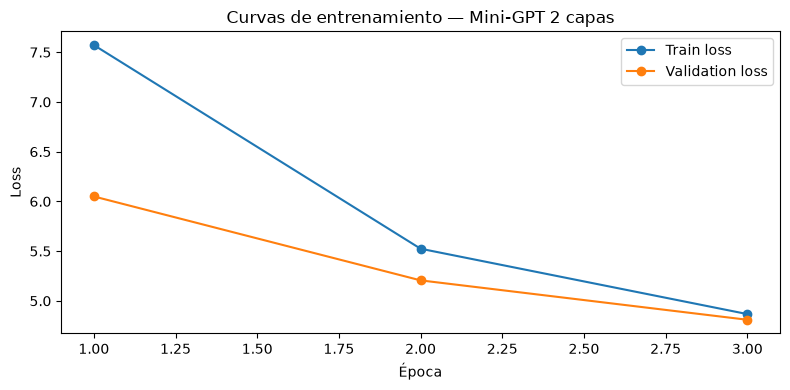

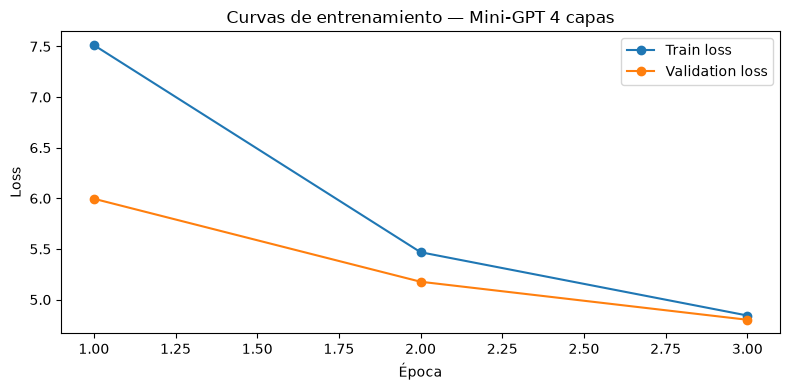

In [19]:
for nombre, history in historias.items():

    plt.figure(figsize=(8, 4))

    plt.plot(
        history["epoch"],
        history["train_loss"],
        marker="o",
        label="Train loss"
    )

    plt.plot(
        history["epoch"],
        history["val_loss"],
        marker="o",
        label="Validation loss"
    )

    plt.title(
        f"Curvas de entrenamiento — {nombre}"
    )

    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 15. Selección del mejor modelo

El modelo se selecciona exclusivamente con **Validation Loss**.

Test no participa en la selección.

In [20]:
MEJOR_NOMBRE = resultados_df.iloc[0][
    "modelo"
]

mejor_modelo = modelos[
    MEJOR_NOMBRE
]

print(
    "Modelo seleccionado:",
    MEJOR_NOMBRE
)

Modelo seleccionado: Mini-GPT 4 capas


# 16. Evaluación final en Test

In [21]:
test_metrics = evaluar_lm(
    mejor_modelo,
    test_loader
)

print("TEST LOSS:", round(
    test_metrics["loss"],
    4
))

print("TEST PERPLEXITY:", round(
    test_metrics["perplexity"],
    2
))

TEST LOSS: 4.7671
TEST PERPLEXITY: 117.57


**Interpretación de Test.** El modelo seleccionado obtuvo **Test Loss = 4.7671** y **Test Perplexity = 117.57**. El comportamiento es consistente con validación (loss 4.8012; perplexity 121.65) y no se observa una degradación extrema al pasar a Test. Este conjunto se utiliza únicamente para la evaluación final, no para seleccionar el modelo.

# 17. Generación autoregresiva

Durante la generación, el modelo recibe un prompt y predice nuevos tokens de manera autoregresiva.

Se probarán:

1. **Greedy decoding**: siempre toma el token más probable.
2. **Sampling con temperatura**.
3. **Sampling con temperatura + top-k**.

Esto permite observar el equilibrio entre coherencia y diversidad.

In [34]:
def generar_texto(
    prompt,
    model,
    max_new_tokens=50,
    do_sample=True,
    temperature=0.8,
    top_k=40,
    top_p=1.0
):
    model.eval()

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    )

    input_ids = inputs[
        "input_ids"
    ].to(DEVICE)

    attention_mask = inputs[
        "attention_mask"
    ].to(DEVICE)

    kwargs = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "max_new_tokens": max_new_tokens,
        "pad_token_id": tokenizer.eos_token_id,
        "eos_token_id": tokenizer.eos_token_id,
        "do_sample": do_sample
    }

    if do_sample:
        kwargs["temperature"] = temperature
        kwargs["top_k"] = top_k
        kwargs["top_p"] = top_p

    with torch.no_grad():
        output = model.generate(
            **kwargs
        )

    return tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

# 18. Comparación de estrategias de decodificación

Se utiliza exactamente el mismo prompt para observar el efecto de la decodificación.

In [23]:
PROMPT = "<TITLE> Add support for"

configuraciones_generacion = [
    {
        "nombre": "Greedy",
        "do_sample": False,
        "temperature": 1.0,
        "top_k": 0
    },
    {
        "nombre": "Sampling conservador",
        "do_sample": True,
        "temperature": 0.6,
        "top_k": 30
    },
    {
        "nombre": "Sampling balanceado",
        "do_sample": True,
        "temperature": 0.8,
        "top_k": 40
    },
    {
        "nombre": "Sampling creativo",
        "do_sample": True,
        "temperature": 1.1,
        "top_k": 50
    }
]

generaciones = []

for cfg in configuraciones_generacion:

    texto = generar_texto(
        PROMPT,
        mejor_modelo,
        max_new_tokens=45,
        do_sample=cfg[
            "do_sample"
        ],
        temperature=cfg[
            "temperature"
        ],
        top_k=cfg[
            "top_k"
        ]
    )

    generaciones.append({
        "estrategia": cfg["nombre"],
        "texto": texto
    })

    print("\n" + "=" * 70)
    print(cfg["nombre"])
    print("=" * 70)
    print(texto)


Greedy
<TITLE> Add support for `dataset`
<BODY> ### Describe the bug I am trying to load_dataset. ### Steps to reproduce the bug <CODE> ### Steps to reproduce the bug <CODE>

Sampling conservador
<TITLE> Add support for datasets with datasets when I am trying to to reproduce the bug <CODE> - `.0. The dataset.0.0.0. <URL> ### Steps to reproduce the> the bug <URL> ##

Sampling balanceado
<TITLE> Add support for Dataset
<BODY> ### Describe the bug I can work of the dataset, it to the dataset. For it and the dataset the following datasets and the datasets. After the dataset. A is to load

Sampling creativo
<TITLE> Add support for Datasets: datasets to the feature of `p` for a new Dataset` dataset using `_dataset, and the dataset when I try - **Link:** <URL> (from_proc


## Comparación controlada: greedy, nucleus y temperatura

Se mantiene el mismo prompt y la misma semilla. Top-p se evalúa con temperatura 1.0; las dos temperaturas se comparan sin truncamiento top-k ni nucleus, para separar mejor el efecto de cada estrategia. Las salidas son muestras cualitativas, no una evaluación de calidad técnica.

In [35]:
PROMPT_INNOVACION = "<TITLE> Bug in frontend data grid"

ESTRATEGIAS_INNOVACION = [
    {
        "nombre": "Greedy Search",
        "do_sample": False,
        "temperature": 1.0,
        "top_k": 0,
        "top_p": 1.0
    },
    {
        "nombre": "Top-p (p=0.9)",
        "do_sample": True,
        "temperature": 1.0,
        "top_k": 0,
        "top_p": 0.9
    },
    {
        "nombre": "Temperatura T=0.7",
        "do_sample": True,
        "temperature": 0.7,
        "top_k": 0,
        "top_p": 1.0
    },
    {
        "nombre": "Temperatura T=1.0",
        "do_sample": True,
        "temperature": 1.0,
        "top_k": 0,
        "top_p": 1.0
    }
]

resultados_innovacion = []

for estrategia in ESTRATEGIAS_INNOVACION:
    torch.manual_seed(SEED)
    texto_generado = generar_texto(
        PROMPT_INNOVACION,
        mejor_modelo,
        max_new_tokens=50,
        do_sample=estrategia["do_sample"],
        temperature=estrategia["temperature"],
        top_k=estrategia["top_k"],
        top_p=estrategia["top_p"]
    )
    resultados_innovacion.append({
        "estrategia": estrategia["nombre"],
        "prompt": PROMPT_INNOVACION,
        "generacion": texto_generado
    })
    print(f"\n--- {estrategia['nombre']} ---")
    print(texto_generado)

display(pd.DataFrame(resultados_innovacion))


--- Greedy Search ---
<TITLE> Bug in frontend data grid
<BODY> ### Describe the bug I am trying to load_dataset. ### Steps to reproduce the bug <CODE> ### Steps to reproduce the bug <CODE> ### Steps to reproduce the bug <CODE>

--- Top-p (p=0.9) ---
<TITLE> Bug in frontend data grid in torch/ expects test aink
<BODY> ### bug However. here, 1 on a dataset is found is which data in the split of schema has there and instance features because the pandaset. The dataset to reproduce the hub **

--- Temperatura T=0.7 ---
<TITLE> Bug in frontend data grid in `load_dataset`
<BODY> ## Describe the bug 1.from_dataset. ## Steps to reproduce the bug <URL> I am want to reproduce the bug <CODE> ## Steps to reproduce

--- Temperatura T=1.0 ---
<TITLE> Bug in frontend data grid editorialAD/ expects test aink
<B bug Throw_disk However. here, 1 on a dataset 46 MI is which data suggestions in theBA schema has there and instance features93 and pandaset/ throws Bella to reproduce the hub **


,estrategia,prompt,generacion
0,Greedy Search,<TITLE> Bug in frontend data grid,<TITLE> Bug in frontend data grid\n<BODY> ### ...
1,Top-p (p=0.9),<TITLE> Bug in frontend data grid,<TITLE> Bug in frontend data grid in torch/ ex...
2,Temperatura T=0.7,<TITLE> Bug in frontend data grid,<TITLE> Bug in frontend data grid in `load_dat...
3,Temperatura T=1.0,<TITLE> Bug in frontend data grid,<TITLE> Bug in frontend data grid editorialAD/...


Al revisar las salidas guardadas, lo primero que se nota es que el modelo aprendió algunas palabras y estructuras habituales de los issues, pero todavía repite expresiones y deja frases incompletas.

Greedy reproduce el formato de una incidencia (`Describe the bug`) y vocabulario técnico (`load_dataset`), pero repite `Steps to reproduce the bug <CODE>`. El sampling conservador repite `datasets`, incluye `trying to to reproduce` y la secuencia `.0.0.0.`. El balanceado repite `the dataset`, y el creativo termina en `(from_proc`. En estas muestras hay señales de aprendizaje del dominio, aunque la coherencia sigue siendo limitada.

Las variantes de sampling obtuvieron Distinct-1/2 mayores que greedy en la tabla posterior. Eso refleja más variedad léxica, no necesariamente mejores respuestas. Como en esas pruebas cambian a la vez la temperatura y top-k, no se puede atribuir la diferencia a uno solo de esos parámetros.

# 19. Diversidad léxica de las generaciones

Como complemento al análisis cualitativo se calculan dos indicadores simples:

- **Distinct-1:** proporción de palabras únicas.
- **Distinct-2:** proporción de bigramas únicos.

No representan por sí solos la calidad del texto, pero ayudan a comparar diversidad entre generaciones.

In [24]:
def distinct_n(texto, n=1):
    tokens = normalizar_para_eda(
        texto
    ).split()

    if len(tokens) < n:
        return 0.0

    ngrams = [
        tuple(
            tokens[i:i+n]
        )
        for i in range(
            len(tokens) - n + 1
        )
    ]

    return (
        len(set(ngrams))
        / len(ngrams)
    )


diversidad = []

for item in generaciones:
    diversidad.append({
        "estrategia":
            item["estrategia"],
        "distinct_1":
            distinct_n(
                item["texto"],
                1
            ),
        "distinct_2":
            distinct_n(
                item["texto"],
                2
            )
    })

display(
    pd.DataFrame(diversidad)
)

,estrategia,distinct_1,distinct_2
0,Greedy,0.620690,0.750000
1,Sampling conservador,0.709677,0.900000
2,Sampling balanceado,0.657895,0.918919
3,Sampling creativo,0.821429,1.000000


# 20. Generación de múltiples incidencias

Aquí se prueba si el modelo puede producir varias alternativas a partir de un mismo inicio.

Esto se acerca al posible uso futuro en PRUNIN: ofrecer más de un borrador para que una persona seleccione o edite el más útil.

In [25]:
PROMPTS_PRUNIN = [
    "<TITLE> Error when",
    "<TITLE> Add support for",
    "<TITLE> Improve",
    "<TITLE> Unable to"
]

for prompt in PROMPTS_PRUNIN:

    print("\n" + "#" * 75)
    print("PROMPT:", prompt)
    print("#" * 75)

    for i in range(3):
        texto = generar_texto(
            prompt,
            mejor_modelo,
            max_new_tokens=35,
            do_sample=True,
            temperature=0.8,
            top_k=40
        )

        print(
            f"\nGeneración {i+1}:"
        )
        print(texto)


###########################################################################
PROMPT: <TITLE> Error when
###########################################################################

Generación 1:
<TITLE> Error when a large dataset
<BODY> ### Feature request The dataset with `load_dataset. I have to reproduce the Dataset` and the dataset for [

Generación 2:
<TITLE> Error when to load_datasets_dataset.0.load_dataset` is a dataset when with the dataset with a_dataset_datas

Generación 3:
<TITLE> Error when this following dataset is not not the dataset when not use a way to `p` and to load_split_dataset(dataset. `dataset

###########################################################################
PROMPT: <TITLE> Add support for
###########################################################################

Generación 1:
<TITLE> Add support for error with `dataset` and the `load_dataset`
<BODY> ## Feature request I'm can work can be able to be not a

Generación 2:
<TITLE> Add support for `data

# 21. Demo orientada a PRUNIN

## A. Demo automática y reproducible

La celda siguiente usa una semilla fija y el prompt `<TITLE> Application fails when`. Se ejecuta normalmente con Run All. La salida es un **texto generado por el modelo**, no una incidencia real.

In [ ]:
# Semilla fija para repetir la demo con el mismo modelo y entorno.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

prompt_demo = "<TITLE> Application fails when"
print("DEMO AUTOMÁTICA PRUNIN — OUTPUT GENERADO")
print(generar_texto(
    prompt_demo,
    mejor_modelo,
    max_new_tokens=50,
    do_sample=True,
    temperature=0.8,
    top_k=40
))

## B. Demo interactiva opcional

La celda siguiente únicamente define la función; no solicita entrada durante Run All. Para usarla manualmente, ejecutar en otra celda:

```python
demo_interactiva()
```

Su resultado también es un output generado, no un dato real del corpus.

In [31]:
def demo_interactiva():
    prompt_usuario = input(
        "Escribe el inicio de la incidencia: "
    ).strip()
    
    if not prompt_usuario.startswith(
        "<TITLE>"
    ):
        prompt_usuario = (
            "<TITLE> "
            + prompt_usuario
        )
    
    resultado = generar_texto(
        prompt_usuario,
        mejor_modelo,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.8,
        top_k=40
    )
    
    print("\nGENERACIÓN DEL MODELO")
    print("-" * 70)
    print(resultado)

# Uso manual en otra celda: demo_interactiva()

# 22. Guardado del modelo

Se guardan el modelo y el tokenizador para poder reutilizarlos posteriormente en PRUNIN sin volver a entrenar desde cero.

In [27]:
OUTPUT_DIR = Path(
    "artifacts_taller4_gpt_prunin"
)

OUTPUT_DIR.mkdir(
    exist_ok=True
)

mejor_modelo.save_pretrained(
    OUTPUT_DIR
)

tokenizer.save_pretrained(
    OUTPUT_DIR
)

print(
    "Modelo guardado en:",
    OUTPUT_DIR.resolve()
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en: /Users/andersontrujillor/Documents/universidad /Procesamieno de lenguaje natural/taller 4/artifacts_taller4_gpt_prunin


# 23. Resumen automático del experimento

In [28]:
print("=" * 70)
print("RESUMEN — TALLER 4")
print("=" * 70)

print("\nDataset:")
print(DATASET_ID)

print("\nCorpus:")
print("Issues finales:", len(df))
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nConfiguraciones:")
display(
    pd.DataFrame(EXPERIMENTOS)
)

print("\nResultados Validation:")
display(
    resultados_df
)

print(
    "\nModelo seleccionado:",
    MEJOR_NOMBRE
)

print(
    "Test loss:",
    round(
        test_metrics["loss"],
        4
    )
)

print(
    "Test perplexity:",
    round(
        test_metrics["perplexity"],
        2
    )
)

RESUMEN — TALLER 4

Dataset:
noamaanMulla-03/datasets-issues

Corpus:
Issues finales: 3276
Train: 2620
Validation: 327
Test: 329

Configuraciones:


,id,nombre,n_layer,n_head,n_embd,dropout,learning_rate,epochs
0,E1,Mini-GPT 2 capas,2,4,128,0.1,0.0003,3
1,E2,Mini-GPT 4 capas,4,4,128,0.1,0.0003,3



Resultados Validation:


,modelo,capas,parametros,val_loss,val_perplexity,tiempo_segundos
0,Mini-GPT 4 capas,4,7238528,4.801160,121.651451,28.055956
1,Mini-GPT 2 capas,2,6841984,4.809852,122.713464,28.737637



Modelo seleccionado: Mini-GPT 4 capas
Test loss: 4.7671
Test perplexity: 117.57


# 24. Lectura de los resultados

Durante las tres épocas, la pérdida de entrenamiento y validación disminuyó. Al comparar las configuraciones, el Mini-GPT de 4 capas quedó ligeramente por delante del de 2; la diferencia es pequeña y los tiempos medidos fueron similares.

En las generaciones se reconocen formatos y términos del corpus, pero también aparecen repeticiones y frases incompletas. La diversidad puede aumentar con sampling, aunque eso no asegura que el texto sea coherente ni técnicamente correcto.

# 25. Conclusiones

El corpus final quedó en **3.276 issues**: 2.620 para entrenamiento, 327 para validación y 329 para test. Durante las tres épocas, la validation loss pasó de 6.0498 a 4.8099 en el modelo de 2 capas y de 5.9962 a 4.8012 en el de 4 capas.

Al comparar los dos modelos, el de 4 capas obtuvo un resultado ligeramente mejor: **validation loss 4.8012 y perplexity 121.65**, frente a **4.8099 y 122.71** con 2 capas. La diferencia fue pequeña, así que en esta corrida duplicar la profundidad apenas cambió el desempeño. Los tiempos también fueron parecidos: 28.06 s para 4 capas y 28.74 s para 2; esta medición no permite afirmar que uno sea más eficiente.

El modelo seleccionado obtuvo **test loss 4.7671 y test perplexity 117.57**, valores cercanos a los de validación. La perplexity resume qué tan difícil le resultó predecir los siguientes tokens del conjunto, pero no mide por sí sola la calidad de cada texto generado.

En las salidas aparecen términos y formatos del corpus, como `dataset`, `load_dataset`, `Describe the bug` y `Steps to reproduce the bug`. También hay repeticiones, frases incompletas y secuencias poco naturales. En las muestras guardadas, Distinct-1/2 fue 0.621/0.750 para greedy y 0.821/1.000 para sampling creativo. La mayor diversidad no garantizó coherencia; además, temperatura y top-k variaron juntos en esa comparación.

El modelo sirve como prototipo para proponer borradores de incidencias, pero **no está listo para producción**. Como se entrenó con texto de issues y no con código fuente ni resultados de pruebas, no puede usarse para auditar código ni confirmar defectos. En una plataforma SaaS podría ayudar a completar títulos o descripciones con contexto del proyecto, siempre con verificación humana.

### Limitaciones

- El corpus proviene de un único repositorio y un dominio técnico específico.
- El modelo es pequeño y las generaciones pueden ser plausibles sin ser correctas.
- Las salidas requieren revisión; no deben tratarse como incidencias verificadas.

El trabajo deja preparado un flujo reutilizable de preparación de datos, tokenización, entrenamiento causal, generación y guardado del modelo. Si se vuelve a entrenar, hay que contrastar estas conclusiones con los nuevos resultados.

### Alcance para PRUNIN

Con este entrenamiento, el modelo puede servir como prototipo para completar borradores de títulos o descripciones de incidencias a partir de un prompt. No es un auditor de código: no recibe archivos fuente, no ejecuta pruebas y sus continuaciones pueden ser técnicamente falsas. Para evaluar una función de auditoría harían falta datos de código y defectos verificados, además de pruebas específicas; para autocompletar tickets en un SaaS, cada borrador debe contrastarse con el contexto real del proyecto y quedar sujeto a revisión humana.

# Verificación final

- [ ] Ejecutar `Restart Kernel and Run All`.
- [ ] Confirmar que no haya errores.
- [ ] Revisar que los resultados y gráficos se vean correctamente.
- [ ] Guardar el notebook con sus outputs.
- [ ] Subir la versión final al repositorio de GitHub.

# Prueba manual del modelo

Esta celda permite ingresar manualmente el inicio de una incidencia para observar cómo el modelo genera la continuación. Debe ejecutarse después de haber corrido las celdas de entrenamiento y selección del mejor modelo.

In [33]:
demo_interactiva()


GENERACIÓN DEL MODELO
----------------------------------------------------------------------
<TITLE> La aplicación falla cuando/data.
<BODY> ### Describe the bug I am to all the dataset (dataset to load_dataset` and the same, the `datasets` as the dataset for `train_dataset


En la prueba manual ingresé “La aplicación falla cuando”. El modelo procesó la entrada, pero continuó principalmente en inglés. Esto es esperable porque casi todo el corpus de entrenamiento está en ese idioma. La prueba muestra que acepta una entrada en español, no que pueda mantener una generación bilingüe consistente.